# Import Library

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color

# Load Dataset

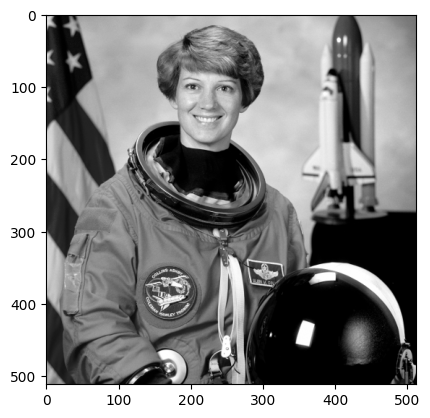

In [8]:
img = color.rgb2gray(data.astronaut())
plt.imshow(img, cmap='gray')
plt.show()

# Fourier Transform

In [ ]:
# Fourier Transform
f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

# High-Pass Filter

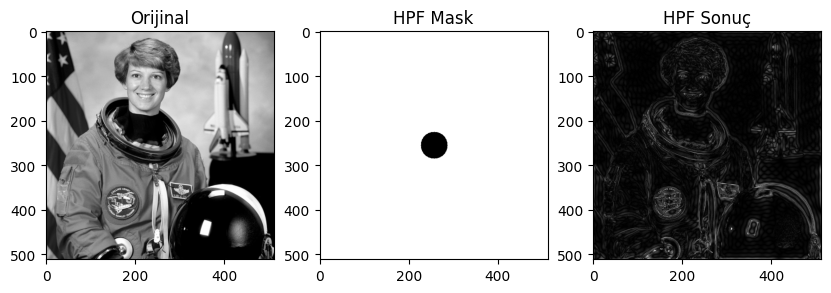

In [9]:
# Mask oluştur (High-pass)
rows, cols = img.shape
crow, ccol = rows//2 , cols//2

mask = np.ones((rows, cols))
r = 30  # yarıçap

for i in range(rows):
    for j in range(cols):
        if (i-crow)**2 + (j-ccol)**2 <= r**2:
            mask[i,j] = 0  # düşük frekansları kaldır

# Filtre uygula
fshift_filtered = fshift * mask

# Ters dönüşüm
f_ishift = np.fft.ifftshift(fshift_filtered)
img_back = np.fft.ifft2(f_ishift)
img_back = np.abs(img_back)

# Görselleştirme
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Orijinal")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("HPF Mask")

plt.subplot(1,3,3)
plt.imshow(img_back, cmap='gray')
plt.title("HPF Sonuç")

plt.show()

# Sharpening

Shapened = Original Image + High Pass

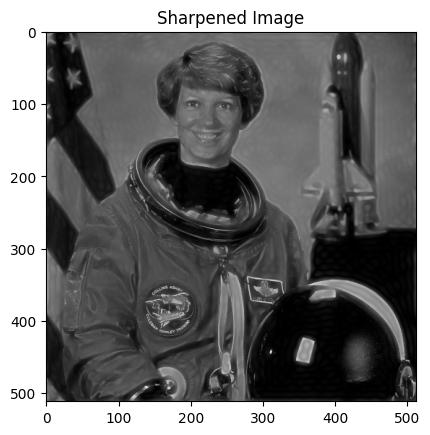

In [10]:
sharpened = img + img_back

plt.imshow(sharpened, cmap='gray')
plt.title("Sharpened Image")
plt.show()

# Band-Pass Filter

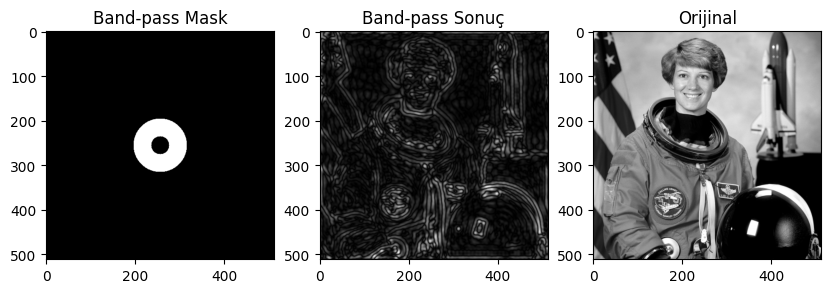

In [11]:
mask = np.zeros((rows, cols))

r1 = 20  # iç yarıçap
r2 = 60  # dış yarıçap

for i in range(rows):
    for j in range(cols):
        dist = (i-crow)**2 + (j-ccol)**2

        if r1**2 < dist < r2**2:
            mask[i,j] = 1

# Filtre uygula
fshift_filtered = fshift * mask

# Ters dönüşüm
f_ishift = np.fft.ifftshift(fshift_filtered)
img_band = np.fft.ifft2(f_ishift)
img_band = np.abs(img_band)

# Görselleştirme
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(mask, cmap='gray')
plt.title("Band-pass Mask")

plt.subplot(1,3,2)
plt.imshow(img_band, cmap='gray')
plt.title("Band-pass Sonuç")

plt.subplot(1,3,3)
plt.imshow(img, cmap='gray')
plt.title("Orijinal")

plt.show()